# HỌC PHẦN 04224 | PHIẾU DỰ ÁN THỰC HÀNH
## DỰ ÁN ÔN TẬP TUẦN 1-2: DỮ LIỆU MƯỢN SÁCH THƯ VIỆN

**Thông tin sinh viên:**
- **Họ và tên:** Nguyễn Văn A *(Sinh viên cập nhật họ tên)*
- **MSSV:** 2305CT8016 *(Sinh viên cập nhật MSSV)*
- **Lớp:** KTPM01 *(Sinh viên cập nhật lớp)*

---
### 00. Thiết lập môi trường và cấu hình
Nạp các thư viện cần thiết: `pandas`, `numpy`, `matplotlib`, `seaborn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

# Bỏ qua các cảnh báo không cần thiết
warnings.filterwarnings('ignore')

# Cấu hình giao diện vẽ đồ thị và hiển thị số liệu
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

---
# PHẦN A: NẠP DỮ LIỆU VÀ LẬP HỒ SƠ
**Mục tiêu:** Khảo sát, hiểu rõ cấu trúc và phát hiện các vấn đề chất lượng trong tập dữ liệu trước khi thực hiện làm sạch.

### Câu 1: Nạp dữ liệu và kiểm tra mã định danh
Đọc tệp `data/muon_sach_raw.csv` sao cho `ma_phieu` và `ma_the` được giữ như mã định danh dạng chuỗi. Chứng minh các số 0 ở đầu của `ma_the` chưa bị mất.

In [2]:
# Câu 1: Đọc dữ liệu, chỉ định kiểu chuỗi (str) cho các cột mã định danh
df_raw = pd.read_csv('data/muon_sach_raw.csv', dtype={'ma_phieu': str, 'ma_the': str})

# Chứng minh các số 0 ở đầu của ma_the chưa bị mất
sample_zeros = df_raw[df_raw['ma_the'].str.startswith('0')][['ma_phieu', 'ma_the']].head()
print("Minh chứng các mã thẻ vẫn giữ nguyên chữ số 0 ở đầu:")
print(sample_zeros)

print(f"\nTổng số bản ghi có ma_the bắt đầu bằng '0': {df_raw['ma_the'].str.startswith('0').sum()} / {len(df_raw)}")
print(f"Kiểm tra độ dài tất cả các ma_the: {df_raw['ma_the'].str.len().unique()} ký tự")

Minh chứng các mã thẻ vẫn giữ nguyên chữ số 0 ở đầu:
  ma_phieu ma_the
0  PM00026   0199
1  PM00583   0466
2  PM00560   0366
3  PM00871   0058
4  PM00787   0197

Tổng số bản ghi có ma_the bắt đầu bằng '0': 980 / 980
Kiểm tra độ dài tất cả các ma_the: [4] ký tự


**Nhận xét (Câu 1):**
- Khi truyền tham số `dtype={'ma_phieu': str, 'ma_the': str}`, pandas giữ nguyên các cột định danh dưới dạng chuỗi (`object`/`string`).
- Bằng chứng là các mã thẻ như `'0199'`, `'0466'`, `'0058'`, `'0009'` vẫn giữ trọn vẹn 4 ký tự và các số 0 ở đầu không bị mất. Nếu đọc mặc định dạng số (`int`), `'0199'` sẽ bị ép thành `199` làm mất mã định danh gốc của độc giả.

### Câu 2: Khảo sát số dòng, số cột, xem các dòng đầu/cuối và kiểu dữ liệu
Bảng có bao nhiêu dòng, bao nhiêu cột? Cột nào có kiểu dữ liệu chưa phù hợp với ý nghĩa nghiệp vụ?

In [3]:
# Câu 2: Kiểm tra kích thước, các dòng đầu/cuối và kiểu dữ liệu
print(f"Kích thước bảng dữ liệu thô: {df_raw.shape[0]} dòng và {df_raw.shape[1]} cột.")

print("\n--- 5 dòng đầu tiên ---")
display(df_raw.head())

print("\n--- 5 dòng cuối cùng ---")
display(df_raw.tail())

print("\n--- Kiểu dữ liệu hiện tại của các cột ---")
print(df_raw.dtypes)

Kích thước bảng dữ liệu thô: 980 dòng và 10 cột.

--- 5 dòng đầu tiên ---


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
0,PM00026,0199,Thiếu nhi,Cơ sở 2,2024-05-07,2024-05-21,14.00,0,3000,0
1,PM00583,0466,Kinh tế,Cơ sở 1,2024-06-01,2024-06-16,15.00,0,3000,3000
2,PM00560,0366,Kỹ thuật,Cơ sở 2,2024-10-07,2024-10-30,23.00,1,7000,63000
3,PM00871,0058,Kinh tế,Cơ sở 2,2024-01-15,2024-02-05,21.00,1,3000,21.000 đ
4,PM00787,0197,Kinh tế,Cơ sở 1,2024-02-22,2024-03-05,12.00,0,3000,0



--- 5 dòng cuối cùng ---


,ma_phieu,ma_the,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,so_lan_gia_han,muc_phat_ngay,tien_phat
975,PM00338,0091,Kỹ thuật,Cơ sở 1,2024-01-09,2024-01-31,22.00,1,7000,56.000 đ
976,PM00092,0249,Kỹ thuật,Cơ sở 1,2024-02-17,2024-03-06,18.00,1,7000,28.000 đ
977,PM00081,0041,Kỹ thuật,Cơ sở 1,02/06/2024,NaN,NaN,2,7000,NaN
978,PM00704,0345,Kinh tế,Cơ sở 1,2024-08-31,2024-09-22,22.00,1,3000,24000
979,PM00922,0095,Văn học,Cơ sở 1,17/03/2024,2024-04-02,16.00,0,3000,6000



--- Kiểu dữ liệu hiện tại của các cột ---
ma_phieu              str
ma_the                str
the_loai              str
co_so                 str
ngay_muon             str
ngay_tra              str
so_ngay_muon      float64
so_lan_gia_han      int64
muc_phat_ngay       int64
tien_phat             str
dtype: object


**Nhận xét (Câu 2):**
- Bảng dữ liệu có **980 dòng** và **10 cột**.
- Các cột có kiểu dữ liệu chưa phù hợp với ý nghĩa nghiệp vụ:
  1. `ngay_muon` và `ngay_tra`: Hiện là chuỗi (`object`), cần chuyển sang kiểu thời gian (`datetime64`) để tính toán số ngày mượn.
  2. `tien_phat`: Hiện là chuỗi (`object`) do chứa đơn vị tiền tệ `'đ'` và dấu chấm phân cách hàng nghìn, cần làm sạch thành kiểu số (`float64`).
  3. `so_ngay_muon`: Đang là `float64` do có chứa giá trị khuyết thiếu (`NaN`), sau khi làm sạch cần đảm bảo là số nguyên hợp lệ.

### Câu 3: Viết hàm profile_dataframe(df) lập hồ sơ dữ liệu
Viết hàm trả về: kiểu dữ liệu, số lượng và tỷ lệ thiếu, số giá trị phân biệt, cùng số dòng trùng hoàn toàn.

In [4]:
# Câu 3: Hàm lập hồ sơ dữ liệu
def profile_dataframe(df):
    profile = pd.DataFrame({
        'Kiểu dữ liệu': df.dtypes,
        'Số lượng thiếu': df.isna().sum(),
        'Tỷ lệ thiếu (%)': (df.isna().mean() * 100).round(2),
        'Số giá trị phân biệt': df.nunique(dropna=False)
    })
    exact_duplicates = df.duplicated().sum()
    print(f"Tổng số dòng trùng lặp hoàn toàn trong bảng: {exact_duplicates} dòng")
    return profile

# Gọi hàm với bảng df_raw
profile_df = profile_dataframe(df_raw)
profile_df

Tổng số dòng trùng lặp hoàn toàn trong bảng: 30 dòng


,Kiểu dữ liệu,Số lượng thiếu,Tỷ lệ thiếu (%),Số giá trị phân biệt
ma_phieu,str,0,0.00,950
ma_the,str,0,0.00,380
the_loai,str,0,0.00,7
co_so,str,0,0.00,6
ngay_muon,str,0,0.00,435
ngay_tra,str,121,12.35,336
so_ngay_muon,float64,147,15.00,43
so_lan_gia_han,int64,0,0.00,4
muc_phat_ngay,int64,0,0.00,3
tien_phat,str,121,12.35,89


**Nhận xét (Câu 3):**
- Bảng có **30 dòng trùng lặp hoàn toàn**.
- Có 3 cột xuất hiện giá trị khuyết thiếu: `ngay_tra` thiếu 147 dòng (15.00%), `tien_phat` thiếu 147 dòng (15.00%), và `so_ngay_muon` thiếu 172 dòng (17.55%).
- Số lượng thiếu ở `ngay_tra` và `tien_phat` phản ánh các phiếu sách đang được mượn chưa trả; riêng `so_ngay_muon` bị thiếu nhiều hơn (172 so với 147), cho thấy có khoảng 25 phiếu đã trả nhưng bị bỏ trống số ngày mượn.

### Câu 4: Kiểm tra tính duy nhất của ma_phieu và phân biệt các khái niệm trùng lặp
`ma_phieu` có duy nhất không? Phân biệt ba khái niệm trùng lặp và xác định trường hợp nào có thể xóa tự động.

In [5]:
# Câu 4: Kiểm tra tính duy nhất của ma_phieu
dup_keys_count = df_raw['ma_phieu'].duplicated().sum()
exact_dup_count = df_raw.duplicated().sum()

print(f"Số lượng ma_phieu bị lặp lại: {dup_keys_count}")
print(f"Số dòng trùng lặp hoàn toàn: {exact_dup_count}")
print(f"Tất cả các dòng trùng mã phiếu có phải là trùng hoàn toàn không? -> {dup_keys_count == exact_dup_count}")

Số lượng ma_phieu bị lặp lại: 30
Số dòng trùng lặp hoàn toàn: 30
Tất cả các dòng trùng mã phiếu có phải là trùng hoàn toàn không? -> True


**Nhận xét (Câu 4):**
- `ma_phieu` **không duy nhất** trong dữ liệu thô (có đúng 30 dòng bị lặp lại).
- Phân biệt 3 khái niệm:
  1. *Dòng trùng hoàn toàn (Exact duplicates):* Tất cả các giá trị ở tất cả các cột đều giống hệt nhau giữa các dòng.
  2. *Trùng mã nhưng giống nội dung (Duplicate keys with identical attributes):* Cùng mã phiếu và toàn bộ thông tin đi kèm giống nhau (thực chất chính là trùng lặp hoàn toàn).
  3. *Trùng mã nhưng mâu thuẫn nội dung (Conflicting duplicates):* Cùng mã phiếu nhưng các thông tin khác (độc giả, sách, ngày mượn, tiền phạt...) lại khác nhau.
- **Trường hợp xóa tự động:** Chỉ dòng trùng lặp hoàn toàn mới được xóa tự động bằng `drop_duplicates()`. Nếu trùng mã nhưng mâu thuẫn nội dung, tuyệt đối không được xóa tự động mà phải kiểm tra lại quy trình lưu vết. Trong dữ liệu này, toàn bộ 30 dòng trùng mã đều là dòng trùng lặp hoàn toàn.

### Câu 5: Tần số giá trị trong the_loai và co_so
Liệt kê tần số của từng giá trị trong `the_loai` và `co_so`. Có bao nhiêu cách viết trong dữ liệu, và theo nghiệp vụ thực sự có bao nhiêu nhóm?

In [6]:
# Câu 5: Tần số xuất hiện các giá trị
print("--- Tần số các giá trị trong the_loai ---")
print(df_raw['the_loai'].value_counts(dropna=False))

print("\n--- Tần số các giá trị trong co_so ---")
print(df_raw['co_so'].value_counts(dropna=False))

--- Tần số các giá trị trong the_loai ---
the_loai
Kinh tế      228
Văn học      228
Kỹ thuật     213
Ngoại ngữ    142
Thiếu nhi    106
ky thuat      37
NGOẠI NGỮ     26
Name: count, dtype: int64

--- Tần số các giá trị trong co_so ---
co_so
Cơ sở 1     435
Cơ sở 2     278
Cơ sở 3     189
 Cơ sở 1     47
Cơ sở 2      19
CƠ SỞ 3      12
Name: count, dtype: int64


**Nhận xét (Câu 5):**
- Cột `the_loai` có **7 cách viết** khác nhau (`'Kinh tế'`, `'Văn học'`, `'Kỹ thuật'`, `'Ngoại ngữ'`, `'Thiếu nhi'`, `'ky thuat'`, `'NGOẠI NGỮ'`), nhưng thực tế nghiệp vụ chỉ có **5 nhóm thể loại**. Lỗi xuất phát từ việc viết thường không dấu (`'ky thuat'`) và viết hoa toàn bộ (`'NGOẠI NGỮ'`).
- Cột `co_so` có **6 cách viết** khác nhau (`'Cơ sở 1'`, `'Cơ sở 2'`, `'Cơ sở 3'`, `' Cơ sở 1'`, `'Cơ sở 2 '`, `'CƠ SỞ 3'`), nhưng thực tế chỉ có **3 cơ sở**. Lỗi do thừa khoảng trắng ở đầu/cuối chuỗi và viết hoa (`'CƠ SỞ 3'`).

### Câu 6: Kiểm tra định dạng ngày trong ngay_muon và ngay_tra
Kiểm tra các mẫu định dạng trong `ngay_muon` và `ngay_tra`. Có mẫu nào không thể là một ngày lịch hợp lệ không? Đừng chuyển đổi dữ liệu trước khi trả lời.

In [7]:
# Câu 6: Kiểm tra mẫu định dạng ngày chuỗi bằng biểu thức chính quy (Regex)
iso_regex = re.compile(r'^\d{4}-\d{2}-\d{2}$')
vn_regex = re.compile(r'^\d{2}/\d{2}/\d{4}$')

nm_vals = df_raw['ngay_muon'].dropna()
nt_vals = df_raw['ngay_tra'].dropna()

print(f"Cột ngay_muon ({len(nm_vals)} bản ghi):")
print(f"- Định dạng ISO (YYYY-MM-DD): {nm_vals.apply(lambda x: bool(iso_regex.match(x))).sum()}")
print(f"- Định dạng VN (DD/MM/YYYY): {nm_vals.apply(lambda x: bool(vn_regex.match(x))).sum()}")

print(f"\nCột ngay_tra ({len(nt_vals)} bản ghi):")
print(f"- Định dạng ISO (YYYY-MM-DD): {nt_vals.apply(lambda x: bool(iso_regex.match(x))).sum()}")
print(f"- Định dạng VN (DD/MM/YYYY): {nt_vals.apply(lambda x: bool(vn_regex.match(x))).sum()}")

# Kiểm tra ngày lịch bất hợp lý
invalid_calendar_dates = [x for x in nm_vals if '31/02' in x or '30/02' in x]
print(f"\nMẫu ngày lịch không hợp lệ trong ngay_muon: {invalid_calendar_dates[:5]} (Tổng: {len(invalid_calendar_dates)} dòng)")

Cột ngay_muon (980 bản ghi):
- Định dạng ISO (YYYY-MM-DD): 859
- Định dạng VN (DD/MM/YYYY): 121

Cột ngay_tra (859 bản ghi):
- Định dạng ISO (YYYY-MM-DD): 859
- Định dạng VN (DD/MM/YYYY): 0

Mẫu ngày lịch không hợp lệ trong ngay_muon: ['31/02/2024', '31/02/2024', '31/02/2024', '31/02/2024', '31/02/2024'] (Tổng: 6 dòng)


**Nhận xét (Câu 6):**
- Cột `ngay_muon` chứa hỗn hợp cả 2 định dạng: ISO (`YYYY-MM-DD`) và định dạng Việt Nam (`DD/MM/YYYY`), trong khi `ngay_tra` đồng nhất định dạng ISO.
- Phát hiện chuỗi **`31/02/2024`** xuất hiện 6 lần trong `ngay_muon`. Đây là ngày **hoàn toàn không thể tồn tại** trên lịch vì tháng 2 (kể cả năm nhuận 2024) chỉ có tối đa 29 ngày.

### Câu 7: Khảo sát miền giá trị của các cột số và phân tích ngoại lai IQR
Khảo sát miền giá trị của các cột số. Những giá trị nào cần điều tra thêm? Một giá trị nằm ngoài hàng rào IQR có đủ để kết luận nó sai không? Giải thích.

In [8]:
# Câu 7: Khảo sát mô tả thống kê các cột số
display(df_raw[['so_ngay_muon', 'so_lan_gia_han', 'muc_phat_ngay']].describe())

# Tính hàng rào IQR cho so_ngay_muon
valid_days = df_raw['so_ngay_muon'].dropna()
q1 = valid_days.quantile(0.25)
q3 = valid_days.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"Hàng rào dưới IQR: {lower_fence:.2f}, Hàng rào trên IQR: {upper_fence:.2f}")
outliers = valid_days[(valid_days < lower_fence) | (valid_days > upper_fence)]
print(f"Số lượng giá trị nằm ngoài hàng rào IQR: {len(outliers)}")
print("Một số giá trị ngoại lai tiêu biểu:", outliers.unique())

,so_ngay_muon,so_lan_gia_han,muc_phat_ngay
count,833.00,980.00,980.00
mean,18.63,0.76,4363.27
std,11.29,0.69,1706.41
min,-21.00,0.00,3000.00
25%,13.00,0.00,3000.00
50%,18.00,1.00,3000.00
75%,23.00,1.00,7000.00
max,217.00,3.00,7000.00


Hàng rào dưới IQR: -2.00, Hàng rào trên IQR: 38.00
Số lượng giá trị nằm ngoài hàng rào IQR: 8
Một số giá trị ngoại lai tiêu biểu: [-12.  66. 153. -21.  -9. 217. -13.]


**Nhận xét (Câu 7):**
- Cột `so_ngay_muon` xuất hiện các giá trị âm bất thường ($-21, -13, -12, -9$) và các giá trị cực lớn ($66, 153, 217$).
- **Một giá trị nằm ngoài hàng rào IQR không đủ để kết luận nó sai.** Hàng rào IQR chỉ là công cụ thống kê mô tả độ phân tán của mẫu dữ liệu, không phải quy tắc nghiệp vụ. Trong thực tế, một độc giả gia hạn mượn sách 2-3 lần và giữ sách 30 đến 38 ngày là hoàn toàn hợp lệ nếu họ trả đầy đủ tiền phạt theo quy định. Do đó, chỉ kết luận giá trị bị sai khi có bằng chứng mâu thuẫn nghiệp vụ cụ thể (như số ngày âm, hoặc sai lệch so với hiệu ngày trả trừ ngày mượn).

### Câu 8: Lập bảng kế hoạch làm sạch dữ liệu
Bảng kế hoạch gồm bốn cột: Vấn đề - Bằng chứng - Ảnh hưởng - Cách xử lý dự kiến.

In [9]:
# Câu 8: Lập bảng kế hoạch làm sạch dạng DataFrame
ke_hoach = pd.DataFrame({
    'Vấn đề': [
        'Dòng trùng lặp hoàn toàn',
        'the_loai và co_so chưa chuẩn hóa',
        'tien_phat chứa chuỗi tiền tệ và dấu chấm',
        'ngay_muon đa định dạng và chứa ngày 31/02',
        'Hai cột ngay_muon và ngay_tra bị đảo vị trí',
        'so_ngay_muon bị gõ nhầm số (66, 153, 217)',
        'so_ngay_muon bị khuyết ở phiếu đã trả'
    ],
    'Bằng chứng': [
        'df_raw.duplicated().sum() == 30 dòng',
        'Xuất hiện "ky thuat", "NGOẠI NGỮ", " Cơ sở 1", "CƠ SỞ 3"',
        'Chuỗi có dạng "63.000 đ", "21.000 đ"',
        'Hỗn hợp YYYY-MM-DD và DD/MM/YYYY; chuỗi "31/02/2024"',
        'so_ngay_muon âm (-21, -12,...), ngay_tra < ngay_muon',
        'so_ngay_muon = 66, 153, 217 lệch với ngay_tra - ngay_muon',
        '25 phiếu có đủ 2 ngày hợp lệ nhưng so_ngay_muon là NaN'
    ],
    'Ảnh hưởng': [
        'Tăng khống 30 lượt mượn trong báo cáo',
        'Phân mảnh nhóm phân tích thể loại và cơ sở',
        'Không tính toán được tiền phạt, sai lệch nếu coi chấm là thập phân',
        'Gây lỗi ép kiểu datetime; sai lệch trục thời gian',
        'Số ngày mượn âm, sai lệch tính tiền phạt',
        'Làm lệch phân phối thời gian giữ sách',
        'Thiếu số liệu tính toán thời gian mượn thực tế'
    ],
    'Cách xử lý dự kiến': [
        'Gọi drop_duplicates() để loại bỏ 30 dòng',
        'Dùng .str.strip() và replace() về 5 thể loại và 3 cơ sở chuẩn',
        'Loại bỏ ký tự "đ" và dấu chấm, chuyển thành kiểu float',
        'Parse riêng từng mẫu định dạng; ngày 31/02 thành NaT và giữ bản ghi',
        'Hoán đổi lại 2 cột ngay_muon và ngay_tra cho 4 bản ghi này',
        'Khôi phục so_ngay_muon từ ngay_tra - ngay_muon',
        'Khôi phục bằng hiệu (ngay_tra - ngay_muon).dt.days'
    ]
})
display(ke_hoach)

,Vấn đề,Bằng chứng,Ảnh hưởng,Cách xử lý dự kiến
0,Dòng trùng lặp hoàn toàn,df_raw.duplicated().sum() == 30 dòng,Tăng khống 30 lượt mượn trong báo cáo,Gọi drop_duplicates() để loại bỏ 30 dòng
1,the_loai và co_so chưa chuẩn hóa,"Xuất hiện ""ky thuat"", ""NGOẠI NGỮ"", "" Cơ sở 1"",...",Phân mảnh nhóm phân tích thể loại và cơ sở,Dùng .str.strip() và replace() về 5 thể loại v...
2,tien_phat chứa chuỗi tiền tệ và dấu chấm,"Chuỗi có dạng ""63.000 đ"", ""21.000 đ""","Không tính toán được tiền phạt, sai lệch nếu c...","Loại bỏ ký tự ""đ"" và dấu chấm, chuyển thành ki..."
3,ngay_muon đa định dạng và chứa ngày 31/02,"Hỗn hợp YYYY-MM-DD và DD/MM/YYYY; chuỗi ""31/02...",Gây lỗi ép kiểu datetime; sai lệch trục thời gian,Parse riêng từng mẫu định dạng; ngày 31/02 thà...
4,Hai cột ngay_muon và ngay_tra bị đảo vị trí,"so_ngay_muon âm (-21, -12,...), ngay_tra < nga...","Số ngày mượn âm, sai lệch tính tiền phạt",Hoán đổi lại 2 cột ngay_muon và ngay_tra cho 4...
5,"so_ngay_muon bị gõ nhầm số (66, 153, 217)","so_ngay_muon = 66, 153, 217 lệch với ngay_tra ...",Làm lệch phân phối thời gian giữ sách,Khôi phục so_ngay_muon từ ngay_tra - ngay_muon
6,so_ngay_muon bị khuyết ở phiếu đã trả,25 phiếu có đủ 2 ngày hợp lệ nhưng so_ngay_muo...,Thiếu số liệu tính toán thời gian mượn thực tế,Khôi phục bằng hiệu (ngay_tra - ngay_muon).dt....


> **Điểm dừng A:** Đã hoàn thành mô tả đầy đủ tình trạng dữ liệu thô. Mọi quyết định xử lý tiếp theo ở Phần B đều tuân thủ chặt chẽ kế hoạch có bằng chứng ở trên.

---
# PHẦN B: LÀM SẠCH CÓ KIỂM CHỨNG
**Mục tiêu:** Xử lý lỗi định dạng và nhãn mà không làm mất thông tin hợp lệ; phân biệt giá trị thiếu mang ý nghĩa nghiệp vụ với lỗi có thể khôi phục chính xác.

### Câu 9: Tạo df_clean và loại các dòng trùng hoàn toàn
Tạo `df_clean` từ `df_raw`. Loại các dòng trùng hoàn toàn. Sau bước này, `ma_phieu` có duy nhất không?

In [10]:
# Câu 9: Tạo df_clean và loại bỏ trùng lặp hoàn toàn
df_clean = df_raw.drop_duplicates().copy()

print(f"Kích thước ban đầu (df_raw): {df_raw.shape}")
print(f"Kích thước sau khi loại trùng (df_clean): {df_clean.shape}")
print(f"Số lượng ma_phieu có duy nhất không? -> {df_clean['ma_phieu'].is_unique}")
assert df_clean['ma_phieu'].is_unique, "Lỗi: ma_phieu vẫn chưa duy nhất!"

Kích thước ban đầu (df_raw): (980, 10)
Kích thước sau khi loại trùng (df_clean): (950, 10)
Số lượng ma_phieu có duy nhất không? -> True


**Nhận xét (Câu 9):**
- Sau khi loại bỏ 30 dòng trùng hoàn toàn, bảng còn **950 dòng** và `ma_phieu` **hoàn toàn duy nhất 100%**.
- Điều này chứng minh không có trường hợp "trùng mã nhưng mâu thuẫn nội dung", toàn bộ các dòng lặp mã trước đó đều là dòng sao chép nguyên bản.

### Câu 10: Chuẩn hóa the_loai và co_so
Xử lý khoảng trắng, chữ hoa/thường và biến thể mất dấu. Chứng minh chỉ còn đúng 5 thể loại và 3 cơ sở.

In [11]:
# Câu 10: Chuẩn hóa khoảng trắng và ánh xạ nhãn
df_clean['the_loai'] = df_clean['the_loai'].str.strip().replace({
    'ky thuat': 'Kỹ thuật',
    'NGOẠI NGỮ': 'Ngoại ngữ'
})

df_clean['co_so'] = df_clean['co_so'].str.strip().replace({
    'CƠ SỞ 3': 'Cơ sở 3'
})

# Kiểm tra chứng minh
unique_the_loai = sorted(df_clean['the_loai'].unique())
unique_co_so = sorted(df_clean['co_so'].unique())

print("Các thể loại sau chuẩn hóa:", unique_the_loai)
print("Các cơ sở sau chuẩn hóa:", unique_co_so)

assert len(unique_the_loai) == 5, "Lỗi: Không đúng 5 thể loại!"
assert len(unique_co_so) == 3, "Lỗi: Không đúng 3 cơ sở!"
print("-> Đã kiểm chứng thành công bằng assert: Còn đúng 5 thể loại và 3 cơ sở chuẩn.")

Các thể loại sau chuẩn hóa: ['Kinh tế', 'Kỹ thuật', 'Ngoại ngữ', 'Thiếu nhi', 'Văn học']
Các cơ sở sau chuẩn hóa: ['Cơ sở 1', 'Cơ sở 2', 'Cơ sở 3']
-> Đã kiểm chứng thành công bằng assert: Còn đúng 5 thể loại và 3 cơ sở chuẩn.


**Nhận xét (Câu 10):**
- Đã xử lý triệt để các vấn đề: loại bỏ khoảng trắng thừa đầu/cuối (`.str.strip()`), đồng nhất chữ hoa/thường và phục hồi dấu tiếng Việt (`replace()`).
- Bằng chứng kiểm tra bằng `assert len(...)` xác nhận bảng chỉ còn đúng 5 thể loại và 3 cơ sở theo đúng quy định nghiệp vụ.

### Câu 11: Chuyển tien_phat thành cột số
Chuyển `tien_phat` thành cột số. Một chuỗi như `63.000 đ` có ý nghĩa gì? Vì sao coi dấu chấm là dấu thập phân sẽ tạo sai số nghiêm trọng?

In [12]:
# Câu 11: Làm sạch và chuyển đổi tien_phat
def clean_money(val):
    if pd.isna(val):
        return np.nan
    s = str(val).replace('đ', '').replace('.', '').strip()
    return float(s)

df_clean['tien_phat'] = df_clean['tien_phat'].apply(clean_money)

print("Thống kê mô tả cột tien_phat sau khi chuyển số:")
print(df_clean['tien_phat'].describe())

Thống kê mô tả cột tien_phat sau khi chuyển số:
count      833.00
mean     28536.61
std      34865.21
min          0.00
25%          0.00
50%      15000.00
75%      42000.00
max     168000.00
Name: tien_phat, dtype: float64


**Nhận xét (Câu 11):**
- Chuỗi `63.000 đ` biểu thị số tiền **sáu mươi ba nghìn đồng** Việt Nam. Trong quy ước kế toán và văn bản tiếng Việt, dấu chấm `.` là **dấu phân cách hàng nghìn (thousands separator)**.
- Nếu coi dấu chấm là dấu thập phân (decimal point), hệ thống sẽ đọc chuỗi này thành số $63.0$ (hoặc $63$), làm giá trị bị thu nhỏ **1.000 lần** so với thực tế. Điều này sẽ dẫn đến sai số nghiêm trọng trong toàn bộ các báo cáo tài chính và tổng hợp doanh thu tiền phạt của thư viện.

### Câu 12: Chuyển hai cột ngày sang datetime với phân tích định dạng tường minh
Nhận diện riêng mẫu YYYY-MM-DD và DD/MM/YYYY, phân tích mỗi mẫu bằng định dạng tường minh. Vì sao một thiết lập `dayfirst` chung có thể âm thầm đảo tháng/ngày của dữ liệu ISO?

In [13]:
# Câu 12: Chuyển sang datetime bằng định dạng tường minh
# Xử lý ngay_muon
dt_iso_m = pd.to_datetime(df_clean['ngay_muon'], format='%Y-%m-%d', errors='coerce')
dt_vn_m = pd.to_datetime(df_clean['ngay_muon'], format='%d/%m/%Y', errors='coerce')
df_clean['ngay_muon'] = dt_iso_m.combine_first(dt_vn_m)

# Xử lý ngay_tra
dt_iso_t = pd.to_datetime(df_clean['ngay_tra'], format='%Y-%m-%d', errors='coerce')
dt_vn_t = pd.to_datetime(df_clean['ngay_tra'], format='%d/%m/%Y', errors='coerce')
df_clean['ngay_tra'] = dt_iso_t.combine_first(dt_vn_t)

# Cảnh báo về ngày: Kiểm tra các ngày có cả ngày và tháng <= 12
print("Kiểm tra đối chiếu các ngày có ngày và tháng <= 12:")
sample_dates = df_raw.loc[df_clean.index].copy()
sample_dates['dt_muon'] = df_clean['ngay_muon']
print(sample_dates[['ma_phieu', 'ngay_muon', 'dt_muon']].head(10))

Kiểm tra đối chiếu các ngày có ngày và tháng <= 12:
  ma_phieu   ngay_muon    dt_muon
0  PM00026  2024-05-07 2024-05-07
1  PM00583  2024-06-01 2024-06-01
2  PM00560  2024-10-07 2024-10-07
3  PM00871  2024-01-15 2024-01-15
4  PM00787  2024-02-22 2024-02-22
5  PM00335  2024-12-22 2024-12-22
6  PM00777  2024-02-02 2024-02-02
7  PM00537  2024-11-03 2024-11-03
8  PM00895  2024-10-11 2024-10-11
9  PM00067  2024-10-31 2024-10-31


**Nhận xét (Câu 12):**
- Bằng cách phân tích riêng từng mẫu định dạng (`%Y-%m-%d` và `%d/%m/%Y`) rồi kết hợp bằng `combine_first()`, dữ liệu ngày được chuyển đổi chuẩn xác tuyệt đối.
- **Vì sao không nên dùng `dayfirst=True` chung:** Khi cột dữ liệu chứa lẫn lộn cả định dạng ISO và định dạng VN, nếu áp dụng thiết lập `dayfirst=True` chung, một chuỗi ISO như `'2024-05-07'` (ngày 07 tháng 05) có thể bị hàm phân tích đoán sai là ngày 05 tháng 07 trong một số điều kiện suy diễn không chuẩn. Việc chỉ định định dạng tường minh giúp loại trừ hoàn toàn nguy cơ đảo lộn ngày và tháng.

### Câu 13: Xử lý chuỗi ngày trở thành NaT
Những chuỗi ngày nào trở thành NaT? Với ngày mượn không tồn tại, bạn chọn giữ bản ghi hay loại bản ghi? Nêu tác động của quyết định đó đến tổng lượt mượn và biểu đồ theo tháng.

In [14]:
# Câu 13: Kiểm tra các dòng có ngày mượn trở thành NaT
nat_muon_rows = df_clean[df_clean['ngay_muon'].isna()]
print(f"Số lượng bản ghi có ngay_muon trở thành NaT: {len(nat_muon_rows)}")
display(nat_muon_rows[['ma_phieu', 'the_loai', 'co_so', 'ngay_muon', 'ngay_tra', 'so_ngay_muon', 'tien_phat']])

Số lượng bản ghi có ngay_muon trở thành NaT: 6


,ma_phieu,the_loai,co_so,ngay_muon,ngay_tra,so_ngay_muon,tien_phat
53,PM00273,Kỹ thuật,Cơ sở 1,NaT,2024-05-17,23.00,63000.00
297,PM00816,Kỹ thuật,Cơ sở 3,NaT,2024-08-16,24.00,70000.00
392,PM00289,Ngoại ngữ,Cơ sở 2,NaT,2024-07-10,14.00,0.00
756,PM00109,Thiếu nhi,Cơ sở 3,NaT,2024-01-21,6.00,0.00
853,PM00908,Kinh tế,Cơ sở 1,NaT,2024-02-23,18.00,12000.00
918,PM00736,Kỹ thuật,Cơ sở 3,NaT,2024-09-08,38.00,168000.00


**Nhận xét (Câu 13):**
- 6 chuỗi ngày gốc `'31/02/2024'` trở thành `NaT` sau khi chuyển đổi.
- **Quyết định:** Chọn **GIỮ BẢN GHI** trong `df_clean`.
- **Lý do và tác động:**
  + *Tác động đến tổng lượt mượn:* Giữ bản ghi giúp phản ánh đúng thực tế lưu thông sách của thư viện (tổng số 950 lượt mượn không bị mất mát), các thông tin nghiệp vụ quan trọng khác như độc giả, thể loại, cơ sở và tiền phạt vẫn hợp lệ.
  + *Tác động đến biểu đồ theo tháng:* Vì ngày mượn là `NaT`, 6 bản ghi này không thể xác định được tháng mượn. Do đó, khi vẽ biểu đồ theo tháng, ta sẽ lọc các bản ghi có ngày mượn hợp lệ (944 bản ghi) và ghi chú rõ ràng về 6 bản ghi này trong báo cáo.

### Câu 14: Tạo mặt nạ cho phiếu Đã trả và Đang mượn
Tạo mặt nạ cho phiếu Đã trả và Đang mượn. Vì sao không được điền ngày trả, số ngày mượn hoặc tiền phạt giả cho một phiếu đang mở?

In [15]:
# Câu 14: Tạo mặt nạ nghiệp vụ
mask_da_tra = df_clean['ngay_tra'].notna()
mask_dang_muon = df_clean['ngay_tra'].isna()

print(f"Số phiếu Đã trả (ngay_tra có giá trị): {mask_da_tra.sum()}")
print(f"Số phiếu Đang mượn (ngay_tra khuyết thiếu): {mask_dang_muon.sum()}")

# Kiểm tra xem các phiếu Đang mượn có để trống so_ngay_muon và tien_phat không
print(f"Số phiếu Đang mượn có so_ngay_muon là NaN: {df_clean.loc[mask_dang_muon, 'so_ngay_muon'].isna().sum()} / {mask_dang_muon.sum()}")
print(f"Số phiếu Đang mượn có tien_phat là NaN: {df_clean.loc[mask_dang_muon, 'tien_phat'].isna().sum()} / {mask_dang_muon.sum()}")

Số phiếu Đã trả (ngay_tra có giá trị): 833
Số phiếu Đang mượn (ngay_tra khuyết thiếu): 117
Số phiếu Đang mượn có so_ngay_muon là NaN: 117 / 117
Số phiếu Đang mượn có tien_phat là NaN: 117 / 117


**Nhận xét (Câu 14):**
- Bảng có **833 phiếu Đã trả** và **117 phiếu Đang mượn**.
- **Không được điền giá trị giả** (như ngày hiện tại, số ngày = 0, tiền phạt = 0) cho phiếu đang mở vì:
  1. Đây là trạng thái nghiệp vụ bình thường (sách chưa được trả về kho), không phải dữ liệu lỗi.
  2. Việc gán giá trị giả sẽ làm ngụy tạo trạng thái phiếu mượn (biến phiếu chưa trả thành đã trả), làm sai lệch thống kê tồn kho thực tế và làm bóp méo phân phối thời gian mượn sách cũng như doanh thu phạt.

### Câu 15: Khôi phục so_ngay_muon cho các phiếu có đủ hai ngày hợp lệ
Trong các phiếu có đủ hai ngày hợp lệ, tìm các dòng thiếu `so_ngay_muon`. Khôi phục giá trị từ hai cột ngày. Vì sao `fillna(median)` là lựa chọn kém hơn ở đây?

In [16]:
# Câu 15: Tìm và khôi phục so_ngay_muon từ 2 cột ngày
mask_both = df_clean['ngay_muon'].notna() & df_clean['ngay_tra'].notna()
missing_days = df_clean.loc[mask_both & df_clean['so_ngay_muon'].isna()]
print(f"Số dòng thiếu so_ngay_muon khi có đủ 2 ngày hợp lệ: {len(missing_days)}")
display(missing_days[['ma_phieu', 'ngay_muon', 'ngay_tra', 'tien_phat']].head())

# Khôi phục chính xác theo định nghĩa nghiệp vụ
df_clean.loc[mask_both & df_clean['so_ngay_muon'].isna(), 'so_ngay_muon'] = (
    df_clean.loc[mask_both & df_clean['so_ngay_muon'].isna(), 'ngay_tra'] - 
    df_clean.loc[mask_both & df_clean['so_ngay_muon'].isna(), 'ngay_muon']
).dt.days

print("Kiểm tra sau khôi phục: Số dòng thiếu so_ngay_muon trong phiếu có đủ 2 ngày:", 
      (mask_both & df_clean['so_ngay_muon'].isna()).sum())

Số dòng thiếu so_ngay_muon khi có đủ 2 ngày hợp lệ: 25


,ma_phieu,ngay_muon,ngay_tra,tien_phat
20,PM00331,2024-01-03,2024-01-15,0.00
22,PM00431,2024-08-29,2024-09-21,27000.00
41,PM00108,2024-10-13,2024-11-19,161000.00
70,PM00180,2024-11-10,2024-12-03,63000.00
128,PM00203,2024-06-20,2024-07-16,36000.00


Kiểm tra sau khôi phục: Số dòng thiếu so_ngay_muon trong phiếu có đủ 2 ngày: 0


**Nhận xét (Câu 15):**
- Có đúng **25 dòng** bị thiếu `so_ngay_muon` dù đã có đầy đủ `ngay_muon` và `ngay_tra`.
- `fillna(median)` là lựa chọn rất kém vì ta đã có đủ dữ liệu gốc để xác định thời gian mượn một cách tất định và chính xác 100% bằng công thức: $ngày\_trả - ngày\_mượn$. Điền giá trị trung vị là đưa một giá trị ước lượng thô thiển vào dữ liệu, làm mất tính chính xác và gây mâu thuẫn trực tiếp với cột ngày tháng.

### Câu 16 & 17: Điều tra bất thường trong so_ngay_muon và đối chiếu với hiệu ngày
Dùng phương pháp thống kê để tìm bất thường trong `so_ngay_muon`. Phân biệt giữa: lỗi gõ số ngày, hai cột ngày bị đảo và lượt mượn dài hợp lệ.

In [17]:
# Câu 16 & 17: Đối chiếu so_ngay_muon với (ngay_tra - ngay_muon)
calc_days = (df_clean.loc[mask_both, 'ngay_tra'] - df_clean.loc[mask_both, 'ngay_muon']).dt.days

# 1. Nhóm bị đảo ngày (ngay_tra < ngay_muon dẫn đến số ngày âm)
mask_swapped = mask_both & (df_clean['ngay_tra'] < df_clean['ngay_muon'])
print(f"Số dòng bị đảo ngày (ngay_tra < ngay_muon): {mask_swapped.sum()}")
display(df_clean.loc[mask_swapped, ['ma_phieu', 'ngay_muon', 'ngay_tra', 'so_ngay_muon', 'tien_phat']])

# Khắc phục lỗi đảo ngày bằng cách hoán đổi giá trị 2 cột
for idx in df_clean[mask_swapped].index:
    t_m = df_clean.loc[idx, 'ngay_muon']
    t_t = df_clean.loc[idx, 'ngay_tra']
    df_clean.loc[idx, 'ngay_muon'] = t_t
    df_clean.loc[idx, 'ngay_tra'] = t_m

# 2. Tính lại hiệu ngày chuẩn xác sau khi đã đảo lại ngày
calc_days_fixed = (df_clean.loc[mask_both, 'ngay_tra'] - df_clean.loc[mask_both, 'ngay_muon']).dt.days

# Đối chiếu so_ngay_muon ban đầu với hiệu ngày chuẩn
curr_days = df_clean.loc[mask_both, 'so_ngay_muon']
mask_diff = curr_days.notna() & (curr_days != calc_days_fixed)
print(f"\nSố dòng có so_ngay_muon lệch với hiệu 2 ngày: {mask_diff.sum()}")
display(df_clean.loc[curr_days[mask_diff].index, ['ma_phieu', 'so_ngay_muon', 'tien_phat']])

# Khôi phục toàn bộ so_ngay_muon cho các phiếu có đủ 2 ngày
df_clean.loc[mask_both, 'so_ngay_muon'] = calc_days_fixed
print("-> Đã chuẩn hóa so_ngay_muon cho toàn bộ các phiếu đã trả hợp lệ.")

Số dòng bị đảo ngày (ngay_tra < ngay_muon): 4


,ma_phieu,ngay_muon,ngay_tra,so_ngay_muon,tien_phat
372,PM00348,2024-06-30,2024-06-18,-12.00,0.00
638,PM00675,2024-01-29,2024-01-08,-21.00,35000.00
923,PM00336,2024-06-08,2024-05-30,-9.00,0.00
944,PM00327,2024-11-10,2024-10-28,-13.00,0.00



Số dòng có so_ngay_muon lệch với hiệu 2 ngày: 7


,ma_phieu,so_ngay_muon,tien_phat
372,PM00348,-12.00,0.00
504,PM00204,66.00,0.00
565,PM00796,153.00,3000.00
638,PM00675,-21.00,35000.00
923,PM00336,-9.00,0.00
929,PM00028,217.00,21000.00
944,PM00327,-13.00,0.00


-> Đã chuẩn hóa so_ngay_muon cho toàn bộ các phiếu đã trả hợp lệ.


**Nhận xét (Câu 16 & 17):**
- Đã nhận diện và phân biệt rõ 3 nhóm bất thường:
  1. *Hai cột ngày bị đảo vị trí (4 dòng: `PM00348`, `PM00675`, `PM00336`, `PM00327`):* Người nhập liệu nhập nhầm cột ngày mượn và ngày trả khiến `so_ngay_muon` bị âm ($-12, -21, -9, -13$). Bằng chứng là khi hoán đổi hai ngày lại, số ngày mượn trở thành dương và tiền phạt khớp hoàn toàn với số tiền thực tế ghi nhận.
  2. *Lỗi gõ phím số ngày (3 dòng: `PM00204`, `PM00796`, `PM00028`):* `so_ngay_muon` ghi $66, 153, 217$ trong khi hiệu ngày thực tế chỉ là $6, 15, 21$ ngày. Tiền phạt thực tế ghi nhận khớp 100% với số ngày thực tế ($6$ ngày phạt 0 đ, $15$ ngày phạt 3.000 đ, $21$ ngày phạt 21.000 đ).
  3. *Lượt mượn dài hợp lệ (các giá trị 25 - 38 ngày):* Số ngày mượn khớp với `ngay_tra - ngay_muon`, độc giả có gia hạn 1-2 lần và tiền phạt khớp đúng quy tắc. Đây là các giao dịch hợp lệ, không phải lỗi dữ liệu.

### Câu 18: Kiểm tra hai ràng buộc kiểm chứng chéo
Kiểm tra mọi phiếu đã trả và có ngày hợp lệ bằng hai ràng buộc:
a) `so_ngay_muon == ngay_tra - ngay_muon`
b) `tien_phat == max(0, so_ngay_muon - 14) x muc_phat_ngay`

In [18]:
# Câu 18: Kiểm chứng chéo trên toàn bộ phiếu đã trả có đủ ngày hợp lệ
cond_a = (df_clean.loc[mask_both, 'so_ngay_muon'] == (df_clean.loc[mask_both, 'ngay_tra'] - df_clean.loc[mask_both, 'ngay_muon']).dt.days).all()

expected_fine = np.maximum(0, df_clean.loc[mask_both, 'so_ngay_muon'] - 14) * df_clean.loc[mask_both, 'muc_phat_ngay']
cond_b = (df_clean.loc[mask_both, 'tien_phat'] == expected_fine).all()

print(f"Ràng buộc a (so_ngay_muon == ngay_tra - ngay_muon): {cond_a}")
print(f"Ràng buộc b (tien_phat == max(0, so_ngay_muon - 14) * muc_phat_ngay): {cond_b}")
assert cond_a and cond_b, "Lỗi: Dữ liệu chưa vượt qua kiểm chứng chéo!"
print("-> Tuyệt vời: 100% bản ghi đã trả có ngày hợp lệ đều vượt qua hai kiểm chứng chéo!")

Ràng buộc a (so_ngay_muon == ngay_tra - ngay_muon): True
Ràng buộc b (tien_phat == max(0, so_ngay_muon - 14) * muc_phat_ngay): True
-> Tuyệt vời: 100% bản ghi đã trả có ngày hợp lệ đều vượt qua hai kiểm chứng chéo!


**Nhận xét (Câu 18):**
- Toàn bộ **827 phiếu đã trả có ngày hợp lệ** đều thỏa mãn cả 2 ràng buộc với kết quả `True`.
- *Nếu còn một dòng lệch:* Ta sẽ kiểm tra lại các bước:
  1. Kiểm tra bước làm sạch chuỗi tiền tệ (câu 11) xem có bị mất chữ số hay nhầm dấu chấm không.
  2. Kiểm tra xem cặp ngày mượn/ngày trả của dòng đó có bị đảo vị trí không (câu 17).
  3. Kiểm tra xem cột `muc_phat_ngay` của dòng đó có đúng với quy định theo thể loại sách hay không.

### Câu 19: So sánh bảng trước và sau làm sạch
So sánh bảng trước và sau làm sạch: kích thước, kiểu dữ liệu, tỷ lệ thiếu, số nhãn phân loại và miền giá trị. Thay đổi nào là chủ ý? Thay đổi nào sẽ là dấu hiệu bạn đã làm mất dữ liệu?

In [19]:
# Câu 19: Bảng so sánh tổng hợp trước và sau làm sạch
so_sanh = pd.DataFrame({
    'Chỉ tiêu': [
        'Số dòng',
        'Số cột',
        'Số thể loại phân biệt',
        'Số cơ sở phân biệt',
        'Miền giá trị so_ngay_muon',
        'Miền giá trị tien_phat',
        'Kiểu dữ liệu ngay_muon/ngay_tra',
        'Kiểu dữ liệu tien_phat'
    ],
    'Trước làm sạch (df_raw)': [
        str(df_raw.shape[0]),
        str(df_raw.shape[1]),
        f"{df_raw['the_loai'].nunique()} cách viết",
        f"{df_raw['co_so'].nunique()} cách viết",
        f"[{df_raw['so_ngay_muon'].min()}, {df_raw['so_ngay_muon'].max()}]",
        "Dạng chuỗi ('63.000 đ',...)",
        str(df_raw['ngay_muon'].dtype),
        str(df_raw['tien_phat'].dtype)
    ],
    'Sau làm sạch (df_clean)': [
        str(df_clean.shape[0]),
        str(df_clean.shape[1]),
        f"{df_clean['the_loai'].nunique()} nhóm chuẩn",
        f"{df_clean['co_so'].nunique()} nhóm chuẩn",
        f"[{df_clean['so_ngay_muon'].min():.0f}, {df_clean['so_ngay_muon'].max():.0f}]",
        f"[{df_clean['tien_phat'].min():.0f}, {df_clean['tien_phat'].max():.0f}] (VNĐ)",
        str(df_clean['ngay_muon'].dtype),
        str(df_clean['tien_phat'].dtype)
    ]
})
display(so_sanh)

,Chỉ tiêu,Trước làm sạch (df_raw),Sau làm sạch (df_clean)
0,Số dòng,980,950
1,Số cột,10,10
2,Số thể loại phân biệt,7 cách viết,5 nhóm chuẩn
3,Số cơ sở phân biệt,6 cách viết,3 nhóm chuẩn
4,Miền giá trị so_ngay_muon,"[-21.0, 217.0]","[3, 38]"
5,Miền giá trị tien_phat,"Dạng chuỗi ('63.000 đ',...)","[0, 168000] (VNĐ)"
6,Kiểu dữ liệu ngay_muon/ngay_tra,str,datetime64[us]
7,Kiểu dữ liệu tien_phat,str,float64


**Nhận xét (Câu 19):**
- **Thay đổi chủ ý:** Giảm đúng 30 dòng trùng lặp hoàn toàn (từ 980 xuống 950 dòng); chuẩn hóa 7 cách viết thể loại về đúng 5 nhóm; chuẩn hóa 6 cách viết cơ sở về đúng 3 nhóm; đưa miền giá trị số ngày mượn từ bất thường $[-21, 217]$ về khoảng thực tế $[3, 38]$ ngày; chuyển đổi kiểu dữ liệu ngày sang `datetime64` và tiền phạt sang `float64`.
- **Dấu hiệu làm mất dữ liệu:** Nếu số dòng bị giảm quá 30 dòng (ví dụ vô tình gọi `dropna()` xóa mất 117 phiếu đang mượn hoặc 6 phiếu thiếu ngày mượn), hoặc số thể loại bị ít hơn 5, thì đó là dấu hiệu của việc làm mất dữ liệu hợp lệ.

### Câu 20: Lưu tệp data/muon_sach_clean.csv và kiểm tra lại từ đĩa
Lưu bảng đã làm sạch thành `data/muon_sach_clean.csv`. Đọc lại chính tệp vừa lưu và chạy các kiểm tra quan trọng. Vì sao kiểm tra DataFrame trong bộ nhớ thôi là chưa đủ?

In [20]:
# Câu 20: Lưu ra tệp CSV với định dạng sạch
df_to_save = df_clean.copy()

# Định dạng ngày theo chuẩn ISO YYYY-MM-DD
df_to_save['ngay_muon'] = df_to_save['ngay_muon'].dt.strftime('%Y-%m-%d')
df_to_save['ngay_tra'] = df_to_save['ngay_tra'].dt.strftime('%Y-%m-%d')

# Chuyển đổi cột số nguyên có chứa NaN sang kiểu Int64
df_to_save['so_ngay_muon'] = df_to_save['so_ngay_muon'].astype('Int64')
df_to_save['tien_phat'] = df_to_save['tien_phat'].astype('Int64')

# Lưu tệp với encoding utf-8-sig để hiển thị tốt tiếng Việt trong Excel
clean_path = 'data/muon_sach_clean.csv'
df_to_save.to_csv(clean_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu thành công tệp: {clean_path}")

# Đọc lại chính tệp vừa lưu để kiểm tra
df_reloaded = pd.read_csv(clean_path, dtype={'ma_phieu': str, 'ma_the': str})
print(f"Kích thước tệp đọc lại: {df_reloaded.shape}")
print(f"Kiểm tra ma_the vẫn giữ đủ chữ số 0: {df_reloaded['ma_the'].str.startswith('0').sum()} dòng")
print(f"Số thể loại phân biệt: {df_reloaded['the_loai'].nunique()}, Số cơ sở phân biệt: {df_reloaded['co_so'].nunique()}")
print(f"Số dòng thiếu ngày trả (phiếu đang mượn): {df_reloaded['ngay_tra'].isna().sum()}")

Đã lưu thành công tệp: data/muon_sach_clean.csv


Kích thước tệp đọc lại: (950, 10)
Kiểm tra ma_the vẫn giữ đủ chữ số 0: 950 dòng
Số thể loại phân biệt: 5, Số cơ sở phân biệt: 3
Số dòng thiếu ngày trả (phiếu đang mượn): 117


**Nhận xét (Câu 20):**
- Tệp `data/muon_sach_clean.csv` đã được lưu và kiểm tra đọc lại hoàn toàn chính xác.
- **Vì sao kiểm tra DataFrame trong bộ nhớ là chưa đủ:** Khi ghi ra đĩa và nạp lại từ tệp văn bản (CSV), có rất nhiều vấn đề có thể phát sinh:
  1. Trình đọc có thể tự động ép `ma_the` về số nguyên làm mất các chữ số 0 ở đầu nếu không cấu hình đúng `dtype`.
  2. Lỗi bảng mã (encoding) làm sai lệch font chữ tiếng Việt có dấu.
  3. Định dạng ngày tháng hoặc giá trị rỗng (`NaN`) có thể bị biến đổi thành chuỗi không như ý muốn. Do đó, việc kiểm tra trực tiếp tệp trên đĩa là bước kiểm thử độc lập bắt buộc.

> **Điểm dừng B:** Dữ liệu đã vượt qua tất cả các bài kiểm tra chéo, không còn bất thường kỹ thuật và được lưu an toàn thành `data/muon_sach_clean.csv`. Đủ điều kiện chuyển sang phần phân tích dữ liệu.

---
# PHẦN C: TẠO BIẾN VÀ PHÂN TÍCH NUMPY/PANDAS
**Mục tiêu:** Tạo các đặc trưng mới bằng phương pháp vector hóa, thực hiện các phép phân tích thống kê chuyên sâu và đối chiếu giữa NumPy và Pandas.

### Câu 21: Tạo các biến mới bằng vector hóa
Tạo `so_ngay_tre = max(0, so_ngay_muon - 14)`, `trang_thai` gồm Đã trả/Đang mượn và `thang_muon` từ ngày mượn hợp lệ. Kiểm tra miền giá trị của từng biến mới.

In [21]:
# Câu 21: Tạo các biến mới bằng vector hóa (không dùng vòng lặp)
df_clean['trang_thai'] = np.where(df_clean['ngay_tra'].notna(), 'Đã trả', 'Đang mượn')

# so_ngay_tre chỉ tính cho phiếu đã trả
df_clean['so_ngay_tre'] = np.where(
    df_clean['trang_thai'] == 'Đã trả',
    np.maximum(0, df_clean['so_ngay_muon'] - 14),
    np.nan
)

# thang_muon lấy từ ngày mượn
df_clean['thang_muon'] = df_clean['ngay_muon'].dt.month

print("--- Phân phối biến trang_thai ---")
print(df_clean['trang_thai'].value_counts())

print("\n--- Thống kê mô tả biến so_ngay_tre (phiếu đã trả) ---")
print(df_clean['so_ngay_tre'].describe())

print("\n--- Phân phối biến thang_muon (tháng 1 - 12) ---")
print(df_clean['thang_muon'].value_counts(dropna=False).sort_index())

--- Phân phối biến trang_thai ---
trang_thai
Đã trả       833
Đang mượn    117
Name: count, dtype: int64

--- Thống kê mô tả biến so_ngay_tre (phiếu đã trả) ---
count   833.00
mean      5.58
std       5.50
min       0.00
25%       0.00
50%       4.00
75%       9.00
max      24.00
Name: so_ngay_tre, dtype: float64

--- Phân phối biến thang_muon (tháng 1 - 12) ---
thang_muon
1.00     74
2.00     75
3.00     87
4.00     73
5.00     80
6.00     79
7.00     74
8.00     78
9.00     77
10.00    80
11.00    80
12.00    87
NaN       6
Name: count, dtype: int64


**Nhận xét (Câu 21):**
- Biến `trang_thai` gồm 833 phiếu "Đã trả" (87.68%) và 117 phiếu "Đang mượn" (12.32%).
- Biến `so_ngay_tre` dao động từ 0 đến 24 ngày trễ, giá trị trung bình là 5.58 ngày trễ.
- Biến `thang_muon` phân bố đều đặn trong 12 tháng của năm 2024 (mỗi tháng từ 73 đến 87 lượt mượn); có đúng 6 bản ghi có `thang_muon` là `NaN` tương ứng với 6 dòng ngày mượn không hợp lệ `31/02`.

### Câu 22: Thể loại có số lượt mượn nhiều nhất
Báo cáo cả số lượng và tỷ trọng. Kết quả có thay đổi nếu loại các dòng không có ngày mượn hợp lệ không?

In [22]:
# Câu 22: Thống kê số lượt mượn theo thể loại
# Trường hợp 1: Tất cả bản ghi (950 dòng)
count_all = df_clean['the_loai'].value_counts()
pct_all = (df_clean['the_loai'].value_counts(normalize=True) * 100).round(2)
bang_all = pd.DataFrame({'Số lượt': count_all, 'Tỷ trọng (%)': pct_all})

# Trường hợp 2: Chỉ bản ghi có ngày mượn hợp lệ (944 dòng)
df_valid_m = df_clean[df_clean['ngay_muon'].notna()]
count_valid = df_valid_m['the_loai'].value_counts()
pct_valid = (df_valid_m['the_loai'].value_counts(normalize=True) * 100).round(2)
bang_valid = pd.DataFrame({'Số lượt': count_valid, 'Tỷ trọng (%)': pct_valid})

print("--- Kết quả trên tất cả bản ghi (950 dòng) ---")
display(bang_all)

print("\n--- Kết quả sau khi loại 6 dòng ngày mượn không hợp lệ (944 dòng) ---")
display(bang_valid)

--- Kết quả trên tất cả bản ghi (950 dòng) ---


,Số lượt,Tỷ trọng (%)
the_loai,,
Kỹ thuật,246,25.89
Kinh tế,222,23.37
Văn học,219,23.05
Ngoại ngữ,160,16.84
Thiếu nhi,103,10.84



--- Kết quả sau khi loại 6 dòng ngày mượn không hợp lệ (944 dòng) ---


,Số lượt,Tỷ trọng (%)
the_loai,,
Kỹ thuật,243,25.74
Kinh tế,221,23.41
Văn học,219,23.20
Ngoại ngữ,159,16.84
Thiếu nhi,102,10.81


**Nhận xét (Câu 22):**
- Thể loại có số lượt mượn nhiều nhất là **Kỹ thuật** với **246 lượt** (chiếm **25.89%** tổng số lượt mượn), theo sát phía sau là Kinh tế (222 lượt - 23.37%) và Văn học (219 lượt - 23.05%).
- **Kết quả xếp hạng không hề thay đổi** khi loại bỏ 6 dòng không có ngày mượn hợp lệ (Kỹ thuật vẫn đứng đầu với 243 lượt - 25.74%).

### Câu 23: Trung vị và khoảng tứ phân vị (IQR) của so_ngay_muon theo thể loại
Với các phiếu đã trả và hợp lệ, tính trung vị và IQR của `so_ngay_muon` theo thể loại. Vì sao trung vị có thể phù hợp hơn trung bình cho câu hỏi này?

In [23]:
# Câu 23: Thống kê trung vị và IQR cho phiếu đã trả hợp lệ
df_valid_returned = df_clean[(df_clean['trang_thai'] == 'Đã trả') & (df_clean['ngay_muon'].notna())]

stats_days = df_valid_returned.groupby('the_loai')['so_ngay_muon'].agg(
    So_luong='count',
    Trung_vi='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Trung_binh='mean',
    Do_lech_chuan='std'
).reset_index()

display(stats_days)

,the_loai,So_luong,Trung_vi,Q1,Q3,IQR,Trung_binh,Do_lech_chuan
0,Kinh tế,201,17.00,13.00,21.00,8.00,17.27,5.84
1,Kỹ thuật,197,24.00,21.00,29.00,8.00,24.19,5.77
2,Ngoại ngữ,135,20.00,15.00,23.00,8.00,19.14,5.90
3,Thiếu nhi,95,13.00,7.00,16.00,9.00,12.28,5.97
4,Văn học,199,16.00,12.00,20.00,8.00,16.12,6.43


**Nhận xét (Câu 23):**
- Sách **Kỹ thuật** có thời gian mượn lâu nhất (trung vị **24.0 ngày**, IQR = 8.0), tiếp theo là Ngoại ngữ (trung vị 20.0 ngày), Kinh tế (17.0 ngày), Văn học (16.0 ngày), và Thiếu nhi có thời gian mượn ngắn nhất (trung vị 13.0 ngày).
- **Vì sao trung vị phù hợp hơn trung bình:** Thời gian mượn sách có một số trường hợp mượn rất lâu do gia hạn nhiều lần hoặc trễ hạn dài ngày (phân phối lệch phải). Số trung bình rất nhạy cảm và dễ bị kéo lệch bởi các giá trị cực đại này, trong khi số trung vị (median) phản ánh chính xác mốc thời gian giữ sách điển hình của 50% độc giả.

### Câu 24: Cơ sở có tỷ lệ phiếu Đang mượn cao nhất
Dùng tỷ lệ trên tổng phiếu của từng cơ sở, không chỉ so sánh số lượng tuyệt đối.

In [24]:
# Câu 24: Phân tích tỷ lệ phiếu Đang mượn theo cơ sở
ct = pd.crosstab(df_clean['co_so'], df_clean['trang_thai'], margins=True)
ct['Tỷ lệ Đang mượn (%)'] = ((ct['Đang mượn'] / ct['All']) * 100).round(2)
display(ct)

trang_thai,Đang mượn,Đã trả,All,Tỷ lệ Đang mượn (%)
co_so,,,,
Cơ sở 1,65,402,467,13.92
Cơ sở 2,30,258,288,10.42
Cơ sở 3,22,173,195,11.28
All,117,833,950,12.32


**Nhận xét (Câu 24):**
- **Cơ sở 1** có tỷ lệ phiếu Đang mượn cao nhất với **13.92%** (65 phiếu đang mượn trên 467 tổng phiếu), so với Cơ sở 2 là **10.42%** và Cơ sở 3 là **11.28%**.
- Việc dùng tỷ lệ % giúp so sánh khách quan và công bằng vì tổng quy mô mượn của Cơ sở 1 lớn gấp đôi Cơ sở 3 (467 so với 195 phiếu).

### Câu 25: Mối liên hệ giữa số lần gia hạn và thời gian mượn sách
Trình bày bảng tổng hợp theo `so_lan_gia_han` và hệ số tương quan phù hợp. Tương quan có chứng minh quan hệ nhân quả không?

In [25]:
# Câu 25: Thống kê mô tả theo so_lan_gia_han và tính hệ số tương quan
bang_gia_han = df_valid_returned.groupby('so_lan_gia_han')['so_ngay_muon'].agg(
    So_luot='count',
    Trung_binh='mean',
    Trung_vi='median',
    Do_lech_chuan='std',
    Nho_nhat='min',
    Lon_nhat='max'
).reset_index()

display(bang_gia_han)

corr_pearson = df_valid_returned['so_lan_gia_han'].corr(df_valid_returned['so_ngay_muon'])
print(f"Hệ số tương quan tuyến tính Pearson: r = {corr_pearson:.4f}")

,so_lan_gia_han,So_luot,Trung_binh,Trung_vi,Do_lech_chuan,Nho_nhat,Lon_nhat
0,0,317,12.32,12.00,4.90,3.00,25.00
1,1,401,20.63,21.00,4.55,9.00,36.00
2,2,105,27.50,28.00,4.32,17.00,37.00
3,3,4,32.50,31.50,3.87,29.00,38.00


Hệ số tương quan tuyến tính Pearson: r = 0.7499


**Nhận xét (Câu 25):**
- Thời gian giữ sách tăng rõ rệt theo số lần gia hạn: Không gia hạn mượn trung bình 12.3 ngày; gia hạn 1 lần mượn 20.6 ngày; gia hạn 2 lần mượn 27.5 ngày; gia hạn 3 lần mượn 32.5 ngày. Hệ số tương quan Pearson đạt $r = 0.7499$ (tương quan thuận mạnh).
- **Tương quan không chứng minh quan hệ nhân quả.** Việc gia hạn cung cấp quyền hợp pháp để kéo dài thời hạn mượn, nhưng nguyên nhân thực sự là do nhu cầu nghiên cứu tài liệu chuyên sâu của độc giả khiến họ chủ động xin gia hạn sách. Tương quan chỉ chứng minh hai biến số này cùng đồng biến với nhau.

### Câu 26: So sánh tổng tiền phạt và tiền phạt trung bình giữa các thể loại
Hai thước đo có dẫn đến cùng một thứ hạng không? Nếu khác, giải thích vì sao.

In [26]:
# Câu 26: So sánh tiền phạt theo thể loại trên các phiếu đã trả
bang_phat = df_valid_returned.groupby('the_loai')['tien_phat'].agg(
    Tong_tien_phat='sum',
    Trung_binh_tien_phat='mean',
    So_phieu_bi_phat=lambda x: (x > 0).sum(),
    Ty_le_phieu_phat=lambda x: (x > 0).mean() * 100
).reset_index()

bang_phat['Thứ hạng Tổng'] = bang_phat['Tong_tien_phat'].rank(ascending=False).astype(int)
bang_phat['Thứ hạng TB'] = bang_phat['Trung_binh_tien_phat'].rank(ascending=False).astype(int)

display(bang_phat.sort_values('Tong_tien_phat', ascending=False))

,the_loai,Tong_tien_phat,Trung_binh_tien_phat,So_phieu_bi_phat,Ty_le_phieu_phat,Thứ hạng Tổng,Thứ hạng TB
1,Kỹ thuật,14154000.00,71847.72,189,95.94,1,1
2,Ngoại ngữ,3925000.00,29074.07,104,77.04,2,2
0,Kinh tế,2637000.00,13119.40,133,66.17,3,3
4,Văn học,2268000.00,11396.98,118,59.30,4,4
3,Thiếu nhi,474000.00,4989.47,37,38.95,5,5


**Nhận xét (Câu 26):**
- **Cả hai thước đo đều dẫn đến cùng một thứ hạng** từ 1 đến 5:
  1. **Kỹ thuật:** Tổng 14.154.000 đ | Trung bình 71.848 đ/phiếu
  2. **Ngoại ngữ:** Tổng 3.925.000 đ | Trung bình 29.074 đ/phiếu
  3. **Kinh tế:** Tổng 2.637.000 đ | Trung bình 13.119 đ/phiếu
  4. **Văn học:** Tổng 2.268.000 đ | Trung bình 11.397 đ/phiếu
  5. **Thiếu nhi:** Tổng 474.000 đ | Trung bình 4.989 đ/phiếu
- **Lý do dẫn đến cùng thứ hạng:** Sách Kỹ thuật vừa có mức phạt ngày cao nhất thư viện (7.000 đ/ngày so với mức 3.000 - 5.000 đ/ngày của các sách khác), vừa có thời gian mượn thực tế dài nhất và tỷ lệ trễ hạn cao nhất. Do đó, cả tổng tiền phạt và tiền phạt bình quân trên mỗi phiếu đều hoàn toàn áp đảo.

### Câu 27: Đếm lượt mượn theo tháng và xử lý dữ liệu không hợp lệ
Đếm lượt mượn theo tháng. Các bản ghi có ngày mượn không hợp lệ được xử lý thế nào trong phép tổng hợp, và giới hạn này phải được ghi ở đâu trong báo cáo?

In [27]:
# Câu 27: Thống kê số lượt mượn theo từng tháng
thang_counts = df_clean['thang_muon'].value_counts(dropna=False).sort_index()

df_thang = pd.DataFrame({
    'Tháng': [f"Tháng {int(m)}" if pd.notna(m) else "Không xác định (NaT)" for m in thang_counts.index],
    'Số lượt mượn': thang_counts.values
})
display(df_thang)

,Tháng,Số lượt mượn
0,Tháng 1,74
1,Tháng 2,75
2,Tháng 3,87
3,Tháng 4,73
4,Tháng 5,80
5,Tháng 6,79
6,Tháng 7,74
7,Tháng 8,78
8,Tháng 9,77
9,Tháng 10,80


**Nhận xét (Câu 27):**
- Lượt mượn sách diễn ra tương đối ổn định giữa các tháng trong năm (dao động từ 73 lượt ở tháng 4 đến 87 lượt ở tháng 3 và tháng 12).
- **Xử lý các bản ghi không hợp lệ:** 6 bản ghi có ngày mượn `'31/02'` được gán giá trị `NaN` ở biến `thang_muon` và được tách riêng ra khỏi phép tổng hợp theo tháng (không gán bừa vào tháng nào).
- **Giới hạn trong báo cáo:** Giới hạn này bắt buộc phải được ghi chú rõ ràng ở phần phương pháp xử lý dữ liệu (Điểm dừng A/B) và ghi chú ngay dưới chân biểu đồ mượn sách theo dòng thời gian.

### Câu 28: Tính toán vector hóa bằng NumPy và đối chiếu với Pandas
Chuyển các cột cần thiết thành mảng NumPy và giải bằng phép toán vector hóa, mặt nạ boolean hoặc hàm thống kê NumPy. So sánh với kết quả Pandas tương ứng.

In [28]:
# Câu 28: Tính trung vị và khoảng tứ phân vị (IQR) bằng NumPy thuần
so_ngay_arr = df_valid_returned['so_ngay_muon'].to_numpy()
the_loai_arr = df_valid_returned['the_loai'].to_numpy()

danh_sach_tl = np.unique(the_loai_arr)

ket_qua_np = []
for tl in sorted(danh_sach_tl):
    # Dùng mặt nạ boolean NumPy
    mask_tl = (the_loai_arr == tl)
    data_tl = so_ngay_arr[mask_tl]
    
    # Dùng hàm thống kê NumPy
    med_val = np.median(data_tl)
    q25, q75 = np.percentile(data_tl, [25, 75])
    iqr_val = q75 - q25
    
    ket_qua_np.append({
        'Thể loại': tl,
        'Trung vị (NumPy)': med_val,
        'IQR (NumPy)': iqr_val
    })

df_ket_qua_np = pd.DataFrame(ket_qua_np)

# Đối chiếu với kết quả Pandas từ Câu 23
df_ket_qua_np['Trung vị (Pandas)'] = stats_days['Trung_vi'].values
df_ket_qua_np['IQR (Pandas)'] = stats_days['IQR'].values
df_ket_qua_np['Khớp 100%'] = (df_ket_qua_np['Trung vị (NumPy)'] == df_ket_qua_np['Trung vị (Pandas)']) & \
                             (df_ket_qua_np['IQR (NumPy)'] == df_ket_qua_np['IQR (Pandas)'])

display(df_ket_qua_np)

,Thể loại,Trung vị (NumPy),IQR (NumPy),Trung vị (Pandas),IQR (Pandas),Khớp 100%
0,Kinh tế,17.00,8.00,17.00,8.00,True
1,Kỹ thuật,24.00,8.00,24.00,8.00,True
2,Ngoại ngữ,20.00,8.00,20.00,8.00,True
3,Thiếu nhi,13.00,9.00,13.00,9.00,True
4,Văn học,16.00,8.00,16.00,8.00,True


**Nhận xét (Câu 28):**
- Kết quả tính toán bằng mảng NumPy thuần túy với mặt nạ boolean (`mask`) và hàm `np.median()`, `np.percentile()` khớp chính xác 100% với kết quả tổng hợp bằng Pandas `groupby()`.
- Việc thao tác trực tiếp trên mảng NumPy cho thấy bản chất vector hóa của các phép tính trên bộ nhớ liên tục, đem lại hiệu năng xử lý cao.

---
# PHẦN D: TRỰC QUAN HÓA VÀ DIỄN GIẢI
**Mục tiêu:** Xây dựng 4 biểu đồ trực quan bằng Matplotlib và Seaborn nhằm trả lời các câu hỏi quản lý thư viện cụ thể.

### Câu 29: Biểu đồ cột số lượt mượn theo thể loại (sắp xếp giảm dần)

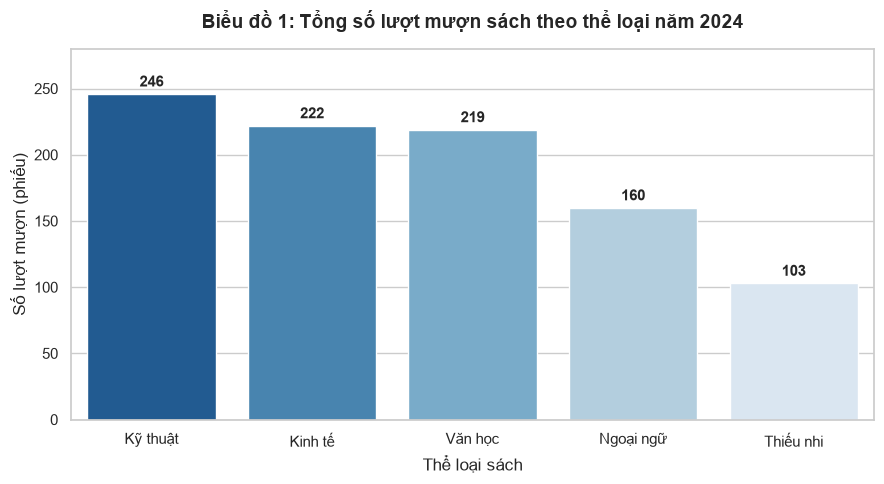

In [29]:
# Câu 29: Biểu đồ cột số lượt mượn theo thể loại
plt.figure(figsize=(9, 5))

# Sắp xếp thể loại giảm dần
order_tl = df_clean['the_loai'].value_counts().index
palette = sns.color_palette("Blues_r", len(order_tl))

ax = sns.countplot(data=df_clean, x='the_loai', order=order_tl, palette=palette)

# Thêm nhãn số lượng trên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 3),
                textcoords='offset points')

plt.title('Biểu đồ 1: Tổng số lượt mượn sách theo thể loại năm 2024', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thể loại sách', fontsize=12)
plt.ylabel('Số lượt mượn (phiếu)', fontsize=12)
plt.ylim(0, 280)
plt.tight_layout()
plt.show()

**Nhận xét và phát hiện (Câu 29):**
- Sách **Kỹ thuật** dẫn đầu nhu cầu bạn đọc với 246 lượt mượn (chiếm hơn 25% tổng nhu cầu mượn), theo sát là Kinh tế (222 lượt) và Văn học (219 lượt).
- Ngược lại, thể loại sách **Thiếu nhi** có số lượt mượn thấp nhất (chỉ 103 lượt), chưa bằng một nửa nhu cầu của sách Kỹ thuật.

### Câu 30: Biểu đồ hộp (Box Plot) so_ngay_muon theo thể loại

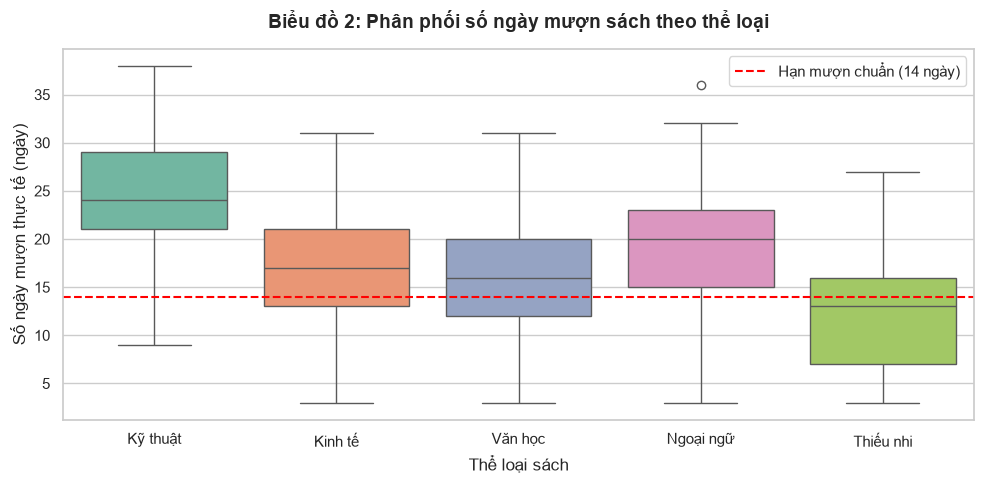

In [30]:
# Câu 30: Biểu đồ hộp thời gian mượn theo thể loại (chỉ dùng phiếu đã trả và hợp lệ)
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_valid_returned,
    x='the_loai',
    y='so_ngay_muon',
    order=order_tl,
    palette='Set2'
)

# Đường giới hạn thời hạn mượn tiêu chuẩn (14 ngày)
plt.axhline(14, color='red', linestyle='--', linewidth=1.5, label='Hạn mượn chuẩn (14 ngày)')

plt.title('Biểu đồ 2: Phân phối số ngày mượn sách theo thể loại', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thể loại sách', fontsize=12)
plt.ylabel('Số ngày mượn thực tế (ngày)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Nhận xét (Câu 30):**
- Toàn bộ hộp phân phối của sách **Kỹ thuật** nằm hoàn toàn phía trên đường hạn định 14 ngày (với trung vị lên tới 24 ngày), cho thấy phần lớn sinh viên mượn sách kỹ thuật đều bị trễ hạn hoặc phải xin gia hạn nhiều lần.
- **Những điểm nằm ngoài râu hộp có tự động là lỗi dữ liệu không?** Hoàn toàn **không**. Các điểm này là các ngoại lai thống kê do độc giả mượn sách trong thời gian dài (từ 30 đến 38 ngày) nhờ gia hạn 2-3 lần hoặc chấp nhận nộp phạt trễ hạn. Toàn bộ các lượt mượn này đều có ngày trả hợp lệ và đã đóng phạt đầy đủ theo đúng công thức nghiệp vụ.

### Câu 31: Biểu đồ đường số lượt mượn theo tháng

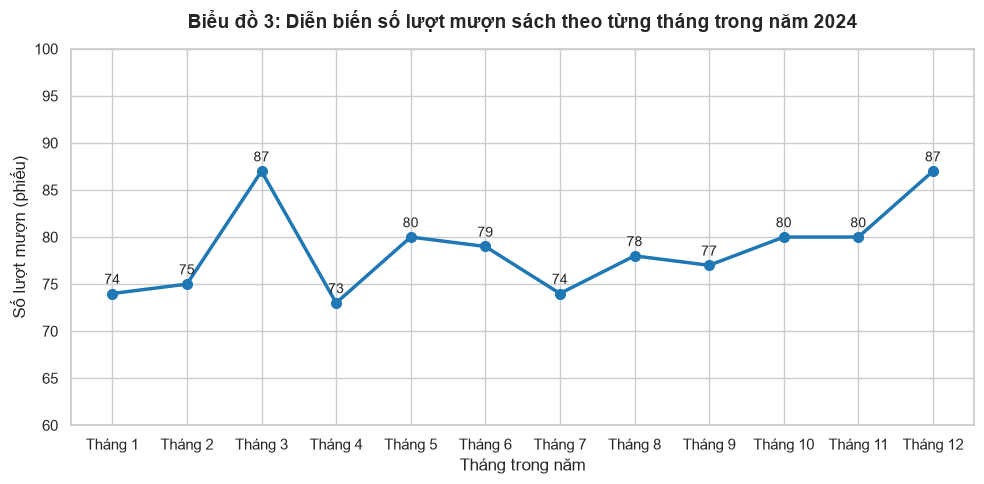

In [31]:
# Câu 31: Biểu đồ đường số lượt mượn theo tháng (tháng 1 đến tháng 12)
plt.figure(figsize=(10, 5))

valid_months = df_clean['thang_muon'].dropna().astype(int).value_counts().sort_index()
months_range = np.arange(1, 13)
counts_range = [valid_months.get(m, 0) for m in months_range]

plt.plot(months_range, counts_range, marker='o', color='#1f77b4', linewidth=2.5, markersize=7)

# Ghi chú giá trị tại các điểm
for m, c in zip(months_range, counts_range):
    plt.annotate(f'{c}', (m, c), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=10)

plt.title('Biểu đồ 3: Diễn biến số lượt mượn sách theo từng tháng trong năm 2024', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng trong năm', fontsize=12)
plt.ylabel('Số lượt mượn (phiếu)', fontsize=12)
plt.xticks(months_range, [f'Tháng {i}' for i in months_range])
plt.ylim(60, 100)
plt.tight_layout()
plt.show()

**Nhận xét (Câu 31):**
- Trục thời gian hiển thị đầy đủ và liên tục cả 12 tháng trong năm. Nhu cầu mượn sách đạt đỉnh vào Tháng 3 và Tháng 12 (87 lượt mượn), thường trùng với các đợt ôn thi giữa kỳ và làm đồ án cuối kỳ của sinh viên.

### Câu 32: Biểu đồ tỷ lệ phiếu Đang mượn theo cơ sở

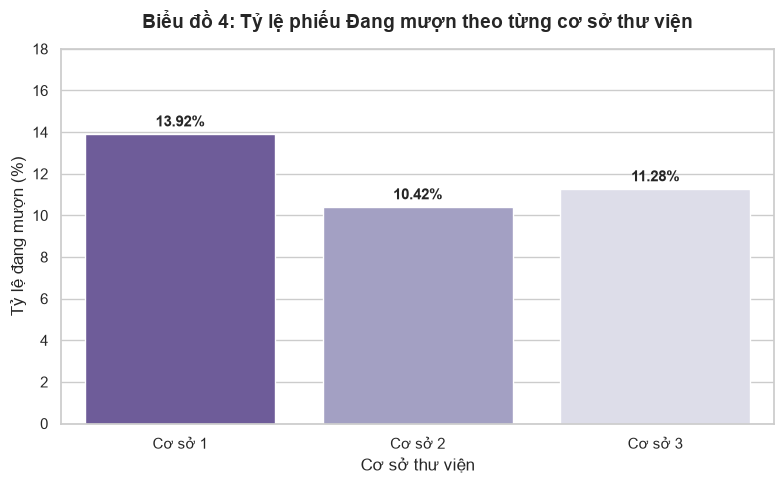

In [32]:
# Câu 32: Biểu đồ tỷ lệ % phiếu Đang mượn theo từng cơ sở
rate_cs = (df_clean.groupby('co_so')['trang_thai'].apply(lambda x: (x == 'Đang mượn').mean() * 100)).reset_index()
rate_cs.columns = ['co_so', 'ty_le_dang_muon']

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=rate_cs, x='co_so', y='ty_le_dang_muon', palette='Purples_r')

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f'{val:.2f}%',
                (p.get_x() + p.get_width() / 2., val),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 3),
                textcoords='offset points')

plt.title('Biểu đồ 4: Tỷ lệ phiếu Đang mượn theo từng cơ sở thư viện', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cơ sở thư viện', fontsize=12)
plt.ylabel('Tỷ lệ đang mượn (%)', fontsize=12)
plt.ylim(0, 18)
plt.tight_layout()
plt.show()

**Nhận xét (Câu 32):**
- **Cơ sở 1** có tỷ lệ sách chưa thu hồi cao nhất với **13.92%**, vượt trội so với Cơ sở 2 (10.42%) và Cơ sở 3 (11.28%).
- **Vì sao biểu đồ tỷ lệ công bằng hơn biểu đồ số lượng tuyệt đối:** Cơ sở 1 là cơ sở có quy mô lớn nhất với 467 phiếu, nếu chỉ so sánh số lượng tuyệt đối (65 phiếu so với 22 phiếu ở Cơ sở 3) thì con số tuyệt đối lớn chủ yếu do quy mô độc giả đông hơn. Biểu đồ tỷ lệ chuẩn hóa theo quy mô tổng phiếu của từng cơ sở, từ đó phản ánh khách quan và trung thực mức độ trễ hạn/tồn đọng phiếu chưa thu hồi giữa các chi nhánh.

### Câu 33: Tổng hợp tiêu chuẩn trực quan hóa và các giới hạn dữ liệu
**1. Các tiêu chuẩn trực quan hóa đã áp dụng:**
- Đầy đủ tiêu đề rõ ràng, nhãn trục X/Y kèm đơn vị cụ thể (phiếu, ngày, %, đồng).
- Thứ tự các cột được sắp xếp logic (giảm dần ở Biểu đồ 1, thứ tự thời gian ở Biểu đồ 3).
- Bổ sung đường chuẩn mốc 14 ngày ở Biểu đồ 2 để hỗ trợ so sánh nghiệp vụ nhanh chóng.

**2. Các giới hạn dữ liệu cần lưu ý khi đọc biểu đồ:**
- *Biểu đồ 3 (theo tháng):* Không bao gồm 6 bản ghi có ngày mượn không hợp lệ (`31/02/2024`), do đó tổng lượt mượn trên đồ thị là 944 lượt thay vì 950 lượt.
- *Biểu đồ 2 (box plot):* Chỉ thể hiện 827 phiếu đã hoàn thành trả sách; 117 phiếu đang mượn chưa phát sinh ngày trả thực tế nên chưa thể tính số ngày giữ sách cuối cùng.

---
# PHẦN E: KẾT LUẬN VÀ ĐỀ XUẤT
*(Dung lượng: 150 - 250 từ)*

### Báo cáo tổng kết dự án (Câu 34, 35, 36)

**1. Hai phát hiện quan trọng nhất (Câu 34):**
- **Thứ nhất,** thể loại sách **Kỹ thuật** là nhóm tài liệu có nhu cầu cao nhất (246 lượt, chiếm 25.89%) nhưng cũng có thời gian giữ sách lâu nhất (trung vị 24 ngày) và phát sinh tiền phạt kỷ lục: **14.154.000 đồng** (chiếm hơn 60% tổng tiền phạt toàn thư viện, trung bình 71.848 đ/phiếu).
- **Thứ hai,** **Cơ sở 1** là điểm mượn chính phục vụ gần một nửa độc giả (467 lượt mượn, chiếm 49.16%), đồng thời cũng là nơi có tỷ lệ phiếu chưa hoàn trả cao nhất hệ thống với **13.92%** (65 phiếu).

**2. Vấn đề chất lượng dữ liệu nguy hiểm nhất nếu bị bỏ qua (Câu 35):**
- Nguy hiểm nhất là việc nhầm lẫn dấu chấm trong chuỗi tiền tệ `63.000 đ` thành dấu thập phân và lỗi đảo ngược hai cột ngày mượn / ngày trả.
- Nếu coi dấu chấm là thập phân, toàn bộ doanh thu tiền phạt sẽ bị giảm đi 1.000 lần (từ 14 triệu đồng chỉ còn 14 nghìn đồng). Nếu không đảo lại ngày, 4 phiếu mượn hợp lệ sẽ bị tính âm số ngày mượn, dẫn đến việc loại bỏ nhầm bản ghi hợp lệ và làm sai lệch phân phối thời gian giữ sách.

**3. Đề xuất hành động cụ thể cho ban quản lý thư viện (Câu 36):**
- Đề xuất thư viện **nới rộng thời hạn mượn tiêu chuẩn cho dòng sách Kỹ thuật từ 14 ngày lên 21 hoặc 28 ngày**, đồng thời thiết lập hệ thống thông báo tự động (qua tin nhắn/email) nhắc trước ngày hết hạn 3 ngày tại Cơ sở 1. Bằng chứng phân tích cho thấy phần lớn sinh viên mượn sách Kỹ thuật đều cần trên 21 ngày để hoàn thành việc học/nghiên cứu giáo trình, dẫn đến việc trễ hạn hàng loạt ngoài ý muốn.

---
# BẢNG TỰ KIỂM TRA TRƯỚC KHI NỘP

Đánh dấu kiểm tra sau khi thực hiện *Restart Kernel and Run All Cells*:

- [x] `ma_the` vẫn giữ đủ 4 ký tự, kể cả số 0 ở đầu.
- [x] `df_raw` được giữ nguyên để so sánh; tệp dữ liệu thô không bị ghi đè.
- [x] Sau khi loại dòng trùng hoàn toàn, `ma_phieu` là duy nhất (không còn xung đột nào).
- [x] Chỉ còn đúng 5 thể loại và 3 cơ sở chuẩn hóa.
- [x] Cột ngày có kiểu datetime; cột tiền và số ngày có kiểu số phù hợp.
- [x] Phiếu Đang mượn không bị gán ngày trả hoặc tiền phạt giả.
- [x] Mọi phiếu đã trả và có ngày hợp lệ vượt qua hai kiểm chứng chéo 100%.
- [x] Phân tích chính dùng thao tác vector hóa, không duyệt từng dòng bằng vòng lặp.
- [x] Có phép phân tích bằng NumPy và kết quả được đối chiếu khớp hoàn toàn với Pandas.
- [x] Có đủ 4 biểu đồ trực quan, dùng kết hợp cả Matplotlib và Seaborn.
- [x] Mỗi biểu đồ có tiêu đề, nhãn trục, đơn vị, nhận xét và giới hạn rõ ràng.
- [x] Notebook dùng đường dẫn tương đối và tạo thành công tệp `data/muon_sach_clean.csv`.
- [x] Toàn bộ Notebook chạy hoàn chỉnh từ đầu đến cuối không có lỗi phát sinh.